## Figure 6

Enviorment: env 1

In [1]:
import pandas as pd
import pickle
import os
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, roc_curve, auc, precision_recall_curve
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix
from scipy.stats import sem
import seaborn as sns
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
from sklearn.metrics import balanced_accuracy_score
import textwrap

import sys
sys.path.append("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/")
from utils import plot_avg_roc_from_dicts, plot_avg_pr_from_dicts, get_test_feat_imp, bl_clean, get_test_pr, get_test_roc

In [2]:
dpi = 300
font_size = 12
fig_size = 5
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "DejaVu Sans"

### load CU CHTN data

#### maternal information

In [3]:
clinical = pd.read_csv("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/clinical_ml_feats_20260430.csv")

### retinal information

In [4]:
all_mets = pd.read_csv("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/rev_chtn_strat_hc_pw/run_20260525_stable/meta_probs_auc_0.5/all_pw_metrics.csv")
result = all_mets.loc[all_mets.groupby('pw')['auc'].idxmax(), ['pw', 'hp', 'auc']]

In [5]:
cu_all_probs = []
for pw in range(1, 6):
    hp = result[result["pw"] == pw]["hp"].iloc[0]
    path = f"/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/rev_chtn_strat_hc_pw{pw}/run_20260525_stable/meta_probs_auc_0.5/XGBoost/{hp}_oof.pkl"
    with open(path, "rb") as f:
        data = pickle.load(f)
        cu_all_probs.append(data[1])
cu_all_probs = pd.DataFrame(cu_all_probs)

In [6]:
cu_all_probs = cu_all_probs.T
cu_all_probs["id"] = cu_all_probs.index
cu_all_probs = cu_all_probs.reset_index(drop=True)
cu_all_probs = cu_all_probs.merge(clinical, how="left")

In [7]:
with open("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/cht_cases_20250926.pkl", "rb") as f:
    chtn = pickle.load(f)

chtn = [id.lower() for id in chtn]
cu_all_probs["label"] = [int(id in chtn) for id in cu_all_probs["id"]]

rename_dict = {}

for i in range(6):
    rename_dict[i] = f"pw_{i + 1}"

cu_all_probs = cu_all_probs.rename(columns=rename_dict)

In [8]:
len(cu_all_probs[~cu_all_probs["pw_1"].isna() | ~cu_all_probs["pw_2"].isna() | ~cu_all_probs["pw_3"].isna() | ~cu_all_probs["pw_4"].isna() | ~cu_all_probs["pw_5"].isna()])

1143

In [9]:
len(cu_all_probs[~cu_all_probs["pw_1"].isna() & ~cu_all_probs["pw_2"].isna() & ~cu_all_probs["pw_3"].isna() & ~cu_all_probs["pw_4"].isna() & ~cu_all_probs["pw_5"].isna()])

61

In [10]:
chtn_all_probs = cu_all_probs.copy()

### load CU GHTN data

#### maternal information

In [11]:
clinical = pd.read_csv("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/clinical_ml_feats_20260430.csv")

#### retinal information

In [12]:
all_mets = pd.read_csv("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/rev_ghtn_strat_hc_pw/run_20260525_stable/meta_probs_auc_0.5/all_pw_metrics.csv")
result = all_mets.loc[all_mets.groupby('pw')['auc'].idxmax(), ['pw', 'hp', 'auc']]

In [13]:
cu_all_probs = []
for pw in range(1, 6):
    hp = result[result["pw"] == pw]["hp"].iloc[0]
    path = f"/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/rev_ghtn_strat_hc_pw{pw}/run_20260525_stable/meta_probs_auc_0.5/XGBoost/{hp}_oof.pkl"
    with open(path, "rb") as f:
        data = pickle.load(f)
        cu_all_probs.append(data[1])
cu_all_probs = pd.DataFrame(cu_all_probs)

In [14]:
cu_all_probs = cu_all_probs.T
cu_all_probs["id"] = cu_all_probs.index
cu_all_probs = cu_all_probs.reset_index(drop=True)
cu_all_probs = cu_all_probs.merge(clinical, how="left")

In [15]:
with open("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/ght_cases_20250926.pkl", "rb") as f:
    ghtn = pickle.load(f)

ghtn = [id.lower() for id in ghtn]
cu_all_probs["label"] = [int(id in ghtn) for id in cu_all_probs["id"]]

rename_dict = {}

for i in range(6):
    rename_dict[i] = f"pw_{i + 1}"

cu_all_probs = cu_all_probs.rename(columns=rename_dict)

In [16]:
len(cu_all_probs[~cu_all_probs["pw_1"].isna() | ~cu_all_probs["pw_2"].isna() | ~cu_all_probs["pw_3"].isna() | ~cu_all_probs["pw_4"].isna() | ~cu_all_probs["pw_5"].isna()])

1138

In [17]:
len(cu_all_probs[~cu_all_probs["pw_1"].isna() & ~cu_all_probs["pw_2"].isna() & ~cu_all_probs["pw_3"].isna() & ~cu_all_probs["pw_4"].isna() & ~cu_all_probs["pw_5"].isna()])

49

### Fig. 6A: ROC and PR

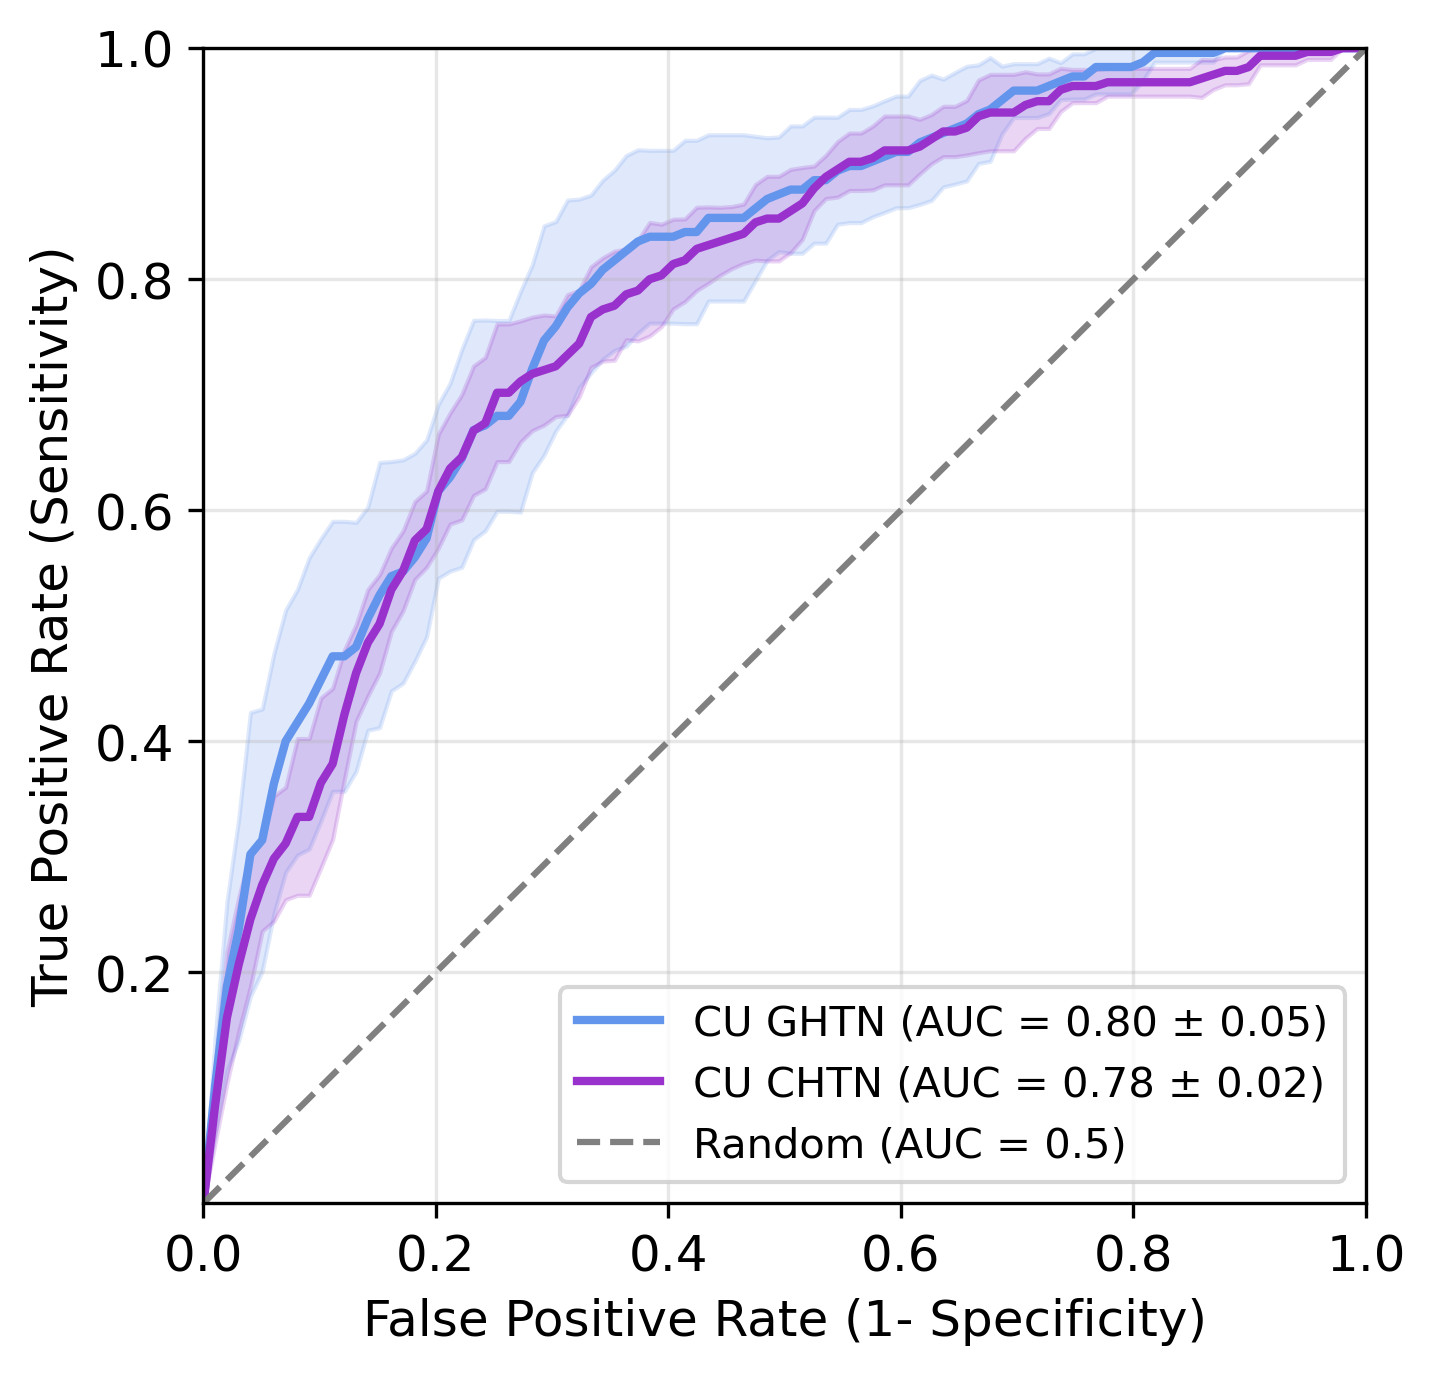

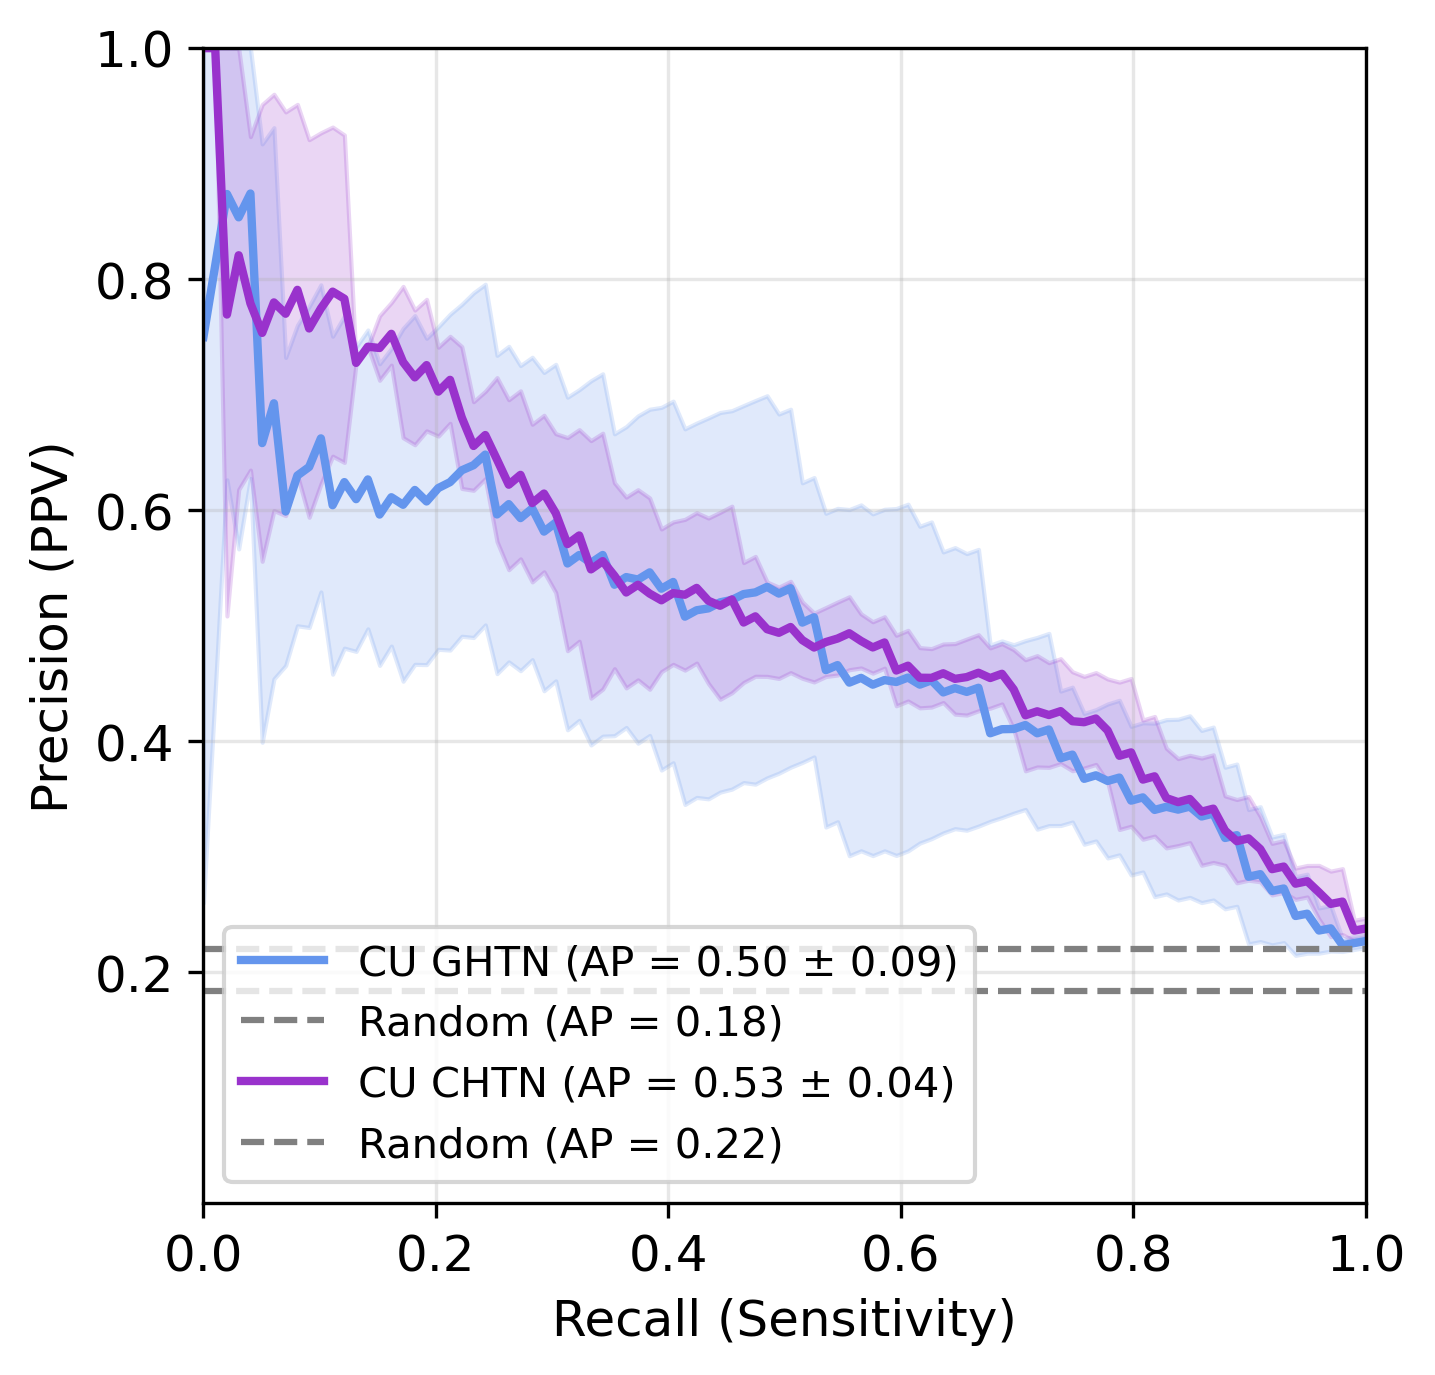

In [18]:
# ROC
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
# retinal
reweight = cu_all_probs.copy()
cols = ["Combo"]
reweight["Combo"] = 0
plot_avg_roc_from_dicts(reweight, title=f"CU GHTN", add_col=cols, plot=True, pw=5, color="cornflowerblue")
# retinal
reweight = chtn_all_probs.copy()
cols = ["Combo"]
reweight["Combo"] = (0.25 * (reweight["First Preg"] * (reweight["Age at enrollment"] > 30).astype(int)))
plot_avg_roc_from_dicts(reweight, title=f"CU CHTN", add_col=cols, plot=True, pw=5, color="darkorchid", rand=True)
plt.title("")
plt.savefig('/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/main_text/fig_6/a_cu_roc.pdf') 
plt.show()

# PR
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
# retinal
reweight = cu_all_probs.copy()
cols = ["Combo"]
reweight["Combo"] = 0
plot_avg_pr_from_dicts(reweight, title=f"CU GHTN", add_col=cols, plot=True, pw=5, color="cornflowerblue", rand=True)
# retinal
reweight = chtn_all_probs.copy()
cols = ["Combo"]
reweight["Combo"] = (0.25 * (reweight["First Preg"] * (reweight["Age at enrollment"] > 30).astype(int)))
plot_avg_pr_from_dicts(reweight, title=f"CU CHTN", add_col=cols, plot=True, pw=5, color="darkorchid", rand=True)

plt.title("")
plt.savefig('/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/main_text/fig_6/a_cu_pr.pdf') 

plt.show()

## nyu combining probs

### fmf

In [19]:
fmf_probs = pd.read_csv("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/data/fmf_pe_results_104.csv")
fmf_probs["id"] = [id.lower() for id in fmf_probs["patient_id"]]
fmf_probs["first_preg"] = [int(val == "Nulliparous") for val in fmf_probs["input_obhist"]]
fmf_probs["prev_pec"] = [int(val == "Parous, prev PE") for val in fmf_probs["input_obhist"]]

In [20]:
fmf_probs["chtn"] = fmf_probs["input_hyp"].astype(int)

### maternal information

In [21]:
nyu_clinical = pd.read_excel("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/Visionary AI Participant Tracker (1).xlsx")
nyu_clinical["id"] = [id.lower() for id in nyu_clinical["Study ID"].fillna("nan")]
nyu_clinical["aspirin"] = [int("yes" in str(val).lower()) for val in nyu_clinical["Recommended Aspirin?"]]

### retinal information

In [22]:
nyu_path = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/nyu/nyu_rg_delivered_testset/"
all_probs = []
all_shap_list = []
for i in range(1, 6):
    path = nyu_path + f"nyu_79_no_repeats_med_ghtn_pec_pw{i}/meta_all_0.5_oof_bls_pw{i}/XGBoost/"
    name = os.listdir(path)[0]
    with open(path + name, "rb") as f:
        data = pickle.load(f)
        for id in data[5].keys():
            all_shap_list.append({"pw": i,"id": id, "shap": data[5][id]})
    all_probs.append(data[1])
all_probs = pd.DataFrame(all_probs)

In [23]:
with open("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/nyu_evaluation.pkl", "rb") as f:
    eval_data = pickle.load(file=f)
ghtn_cases = eval_data["ghtn"]
final_exclusions = eval_data["ex"]

In [24]:
retinal_probs = pd.DataFrame(all_probs.mean(), columns=["retinal"])
retinal_probs["id"] = retinal_probs.index
retinal_probs = retinal_probs.reset_index(drop=True)
retinal_probs = retinal_probs.merge(fmf_probs[["id", "pe_before_delivery_percent", "cohort", "first_preg", "prev_pec", "input_age", "chtn"]], how="outer")
retinal_probs["label"] = retinal_probs["id"].isin(ghtn_cases).astype(int)
retinal_probs = retinal_probs.dropna()

### retinal

In [25]:
ids = list(retinal_probs["id"].values)

In [26]:
ids = list(set(retinal_probs["id"].values) - set(final_exclusions))

In [27]:
len(retinal_probs[retinal_probs["id"].isin(ids)].dropna())

66

In [28]:
sum(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["id"].isin(ghtn_cases))

7

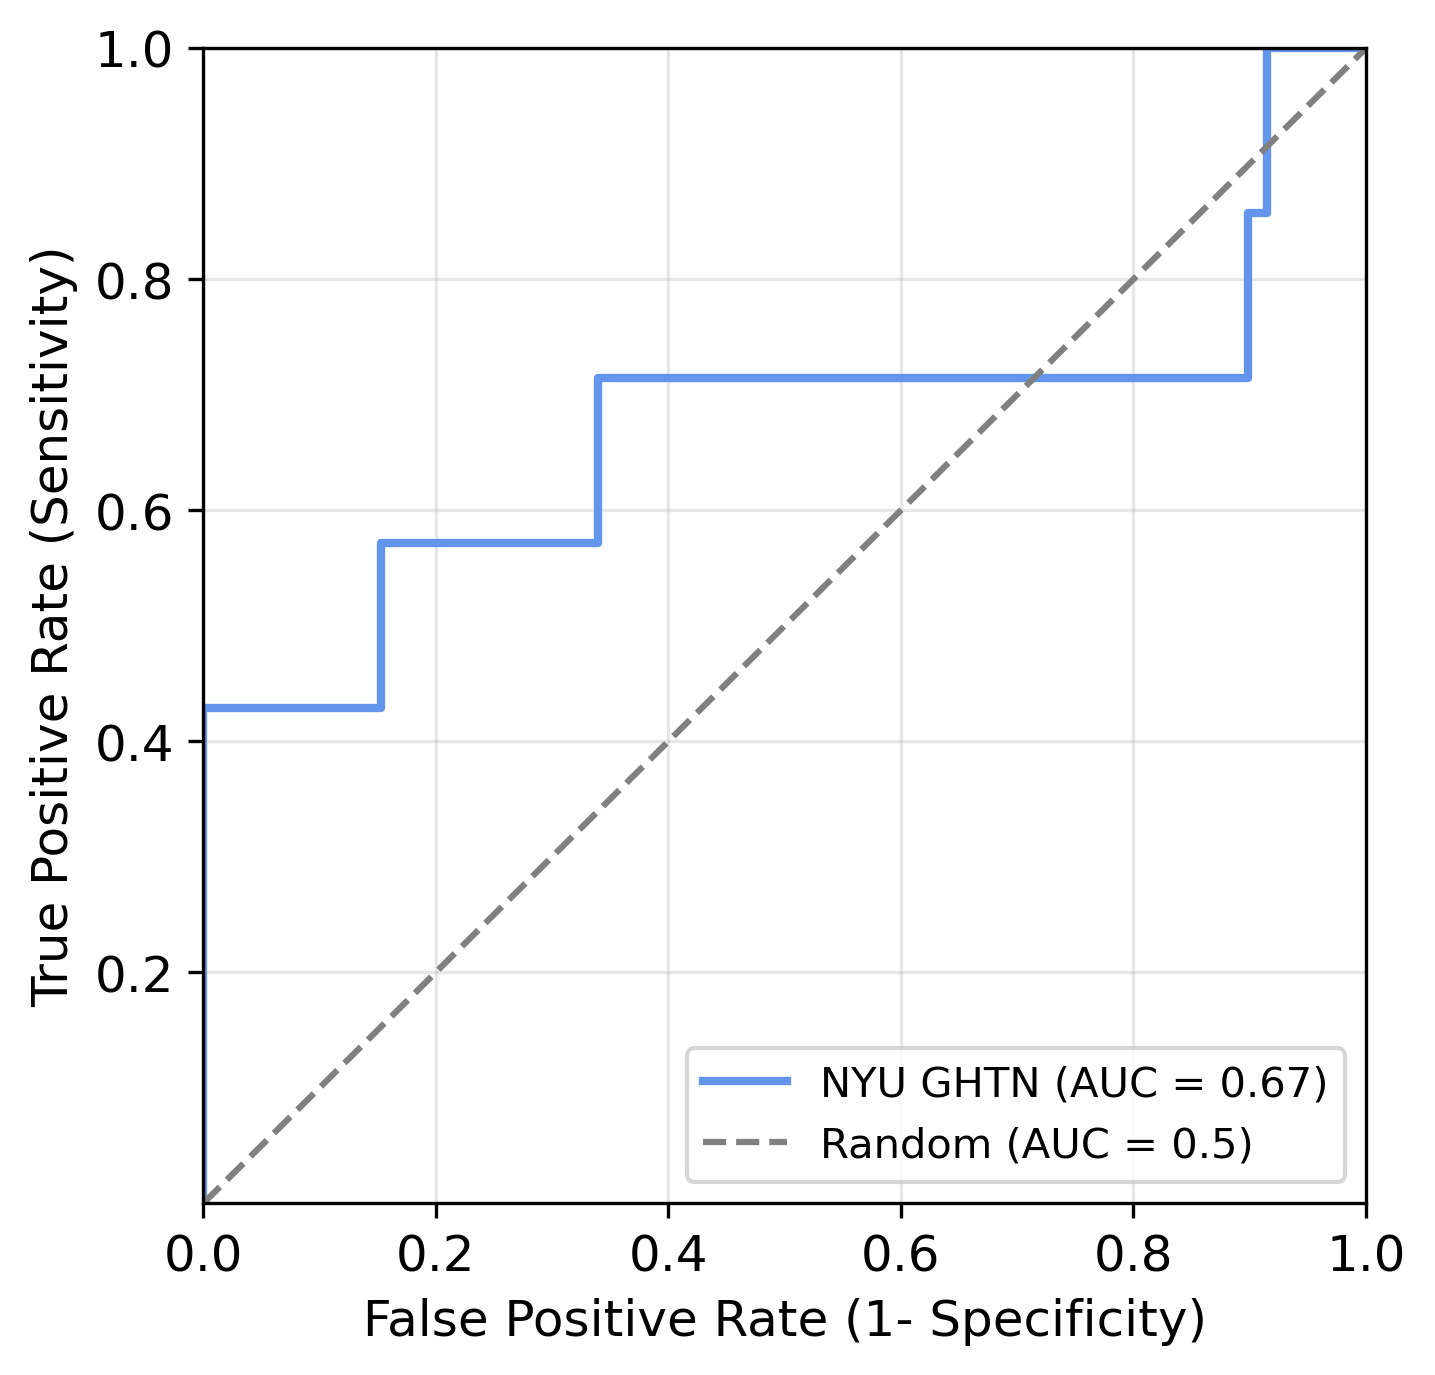

In [29]:
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
retinal_probs["combo"] = (retinal_probs["prev_pec"] * 0.3)

# retinal
get_test_roc(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["label"], retinal_probs[retinal_probs["id"].isin(ids)].dropna()["retinal"] , curve_label="NYU GHTN", color="cornflowerblue", rand=True)

plt.savefig('/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/main_text/fig_6/a_nyu_roc.pdf') 

plt.show()

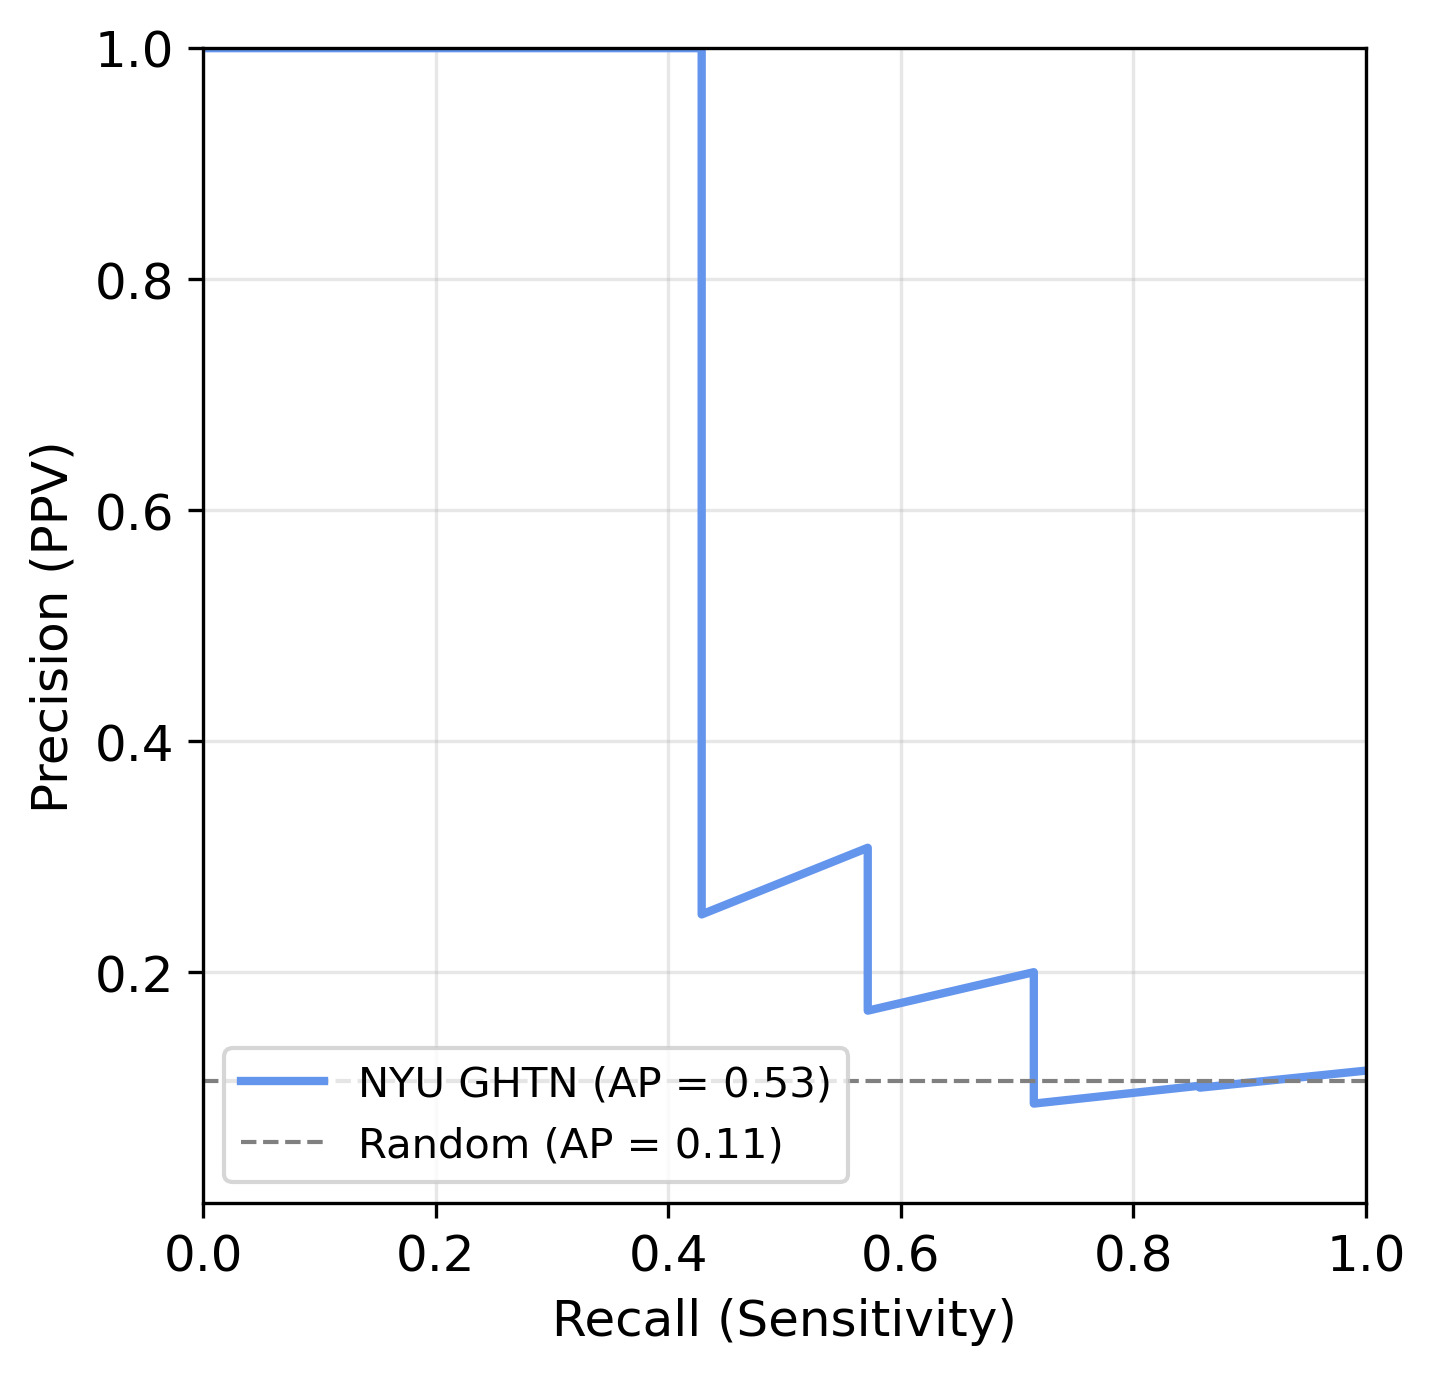

In [30]:

plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
retinal_probs["combo"] = (retinal_probs["prev_pec"] * 0.3)

# retinal
get_test_pr(retinal_probs[retinal_probs["id"].isin(ids)].dropna()["label"], retinal_probs[retinal_probs["id"].isin(ids)].dropna()["retinal"], curve_label="NYU GHTN", color="cornflowerblue", rand=True)
plt.savefig('/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/main_text/fig_6/a_nyu_pr.pdf') 

plt.show()

### Fig. 6B: feature importance

In [31]:
data_name = "rev_ghtn_strat_hc_pw"
train_test_run_models = "run_20260528_model_ghtn_stable"
n_pop = 5
model_type = "XGBoost"

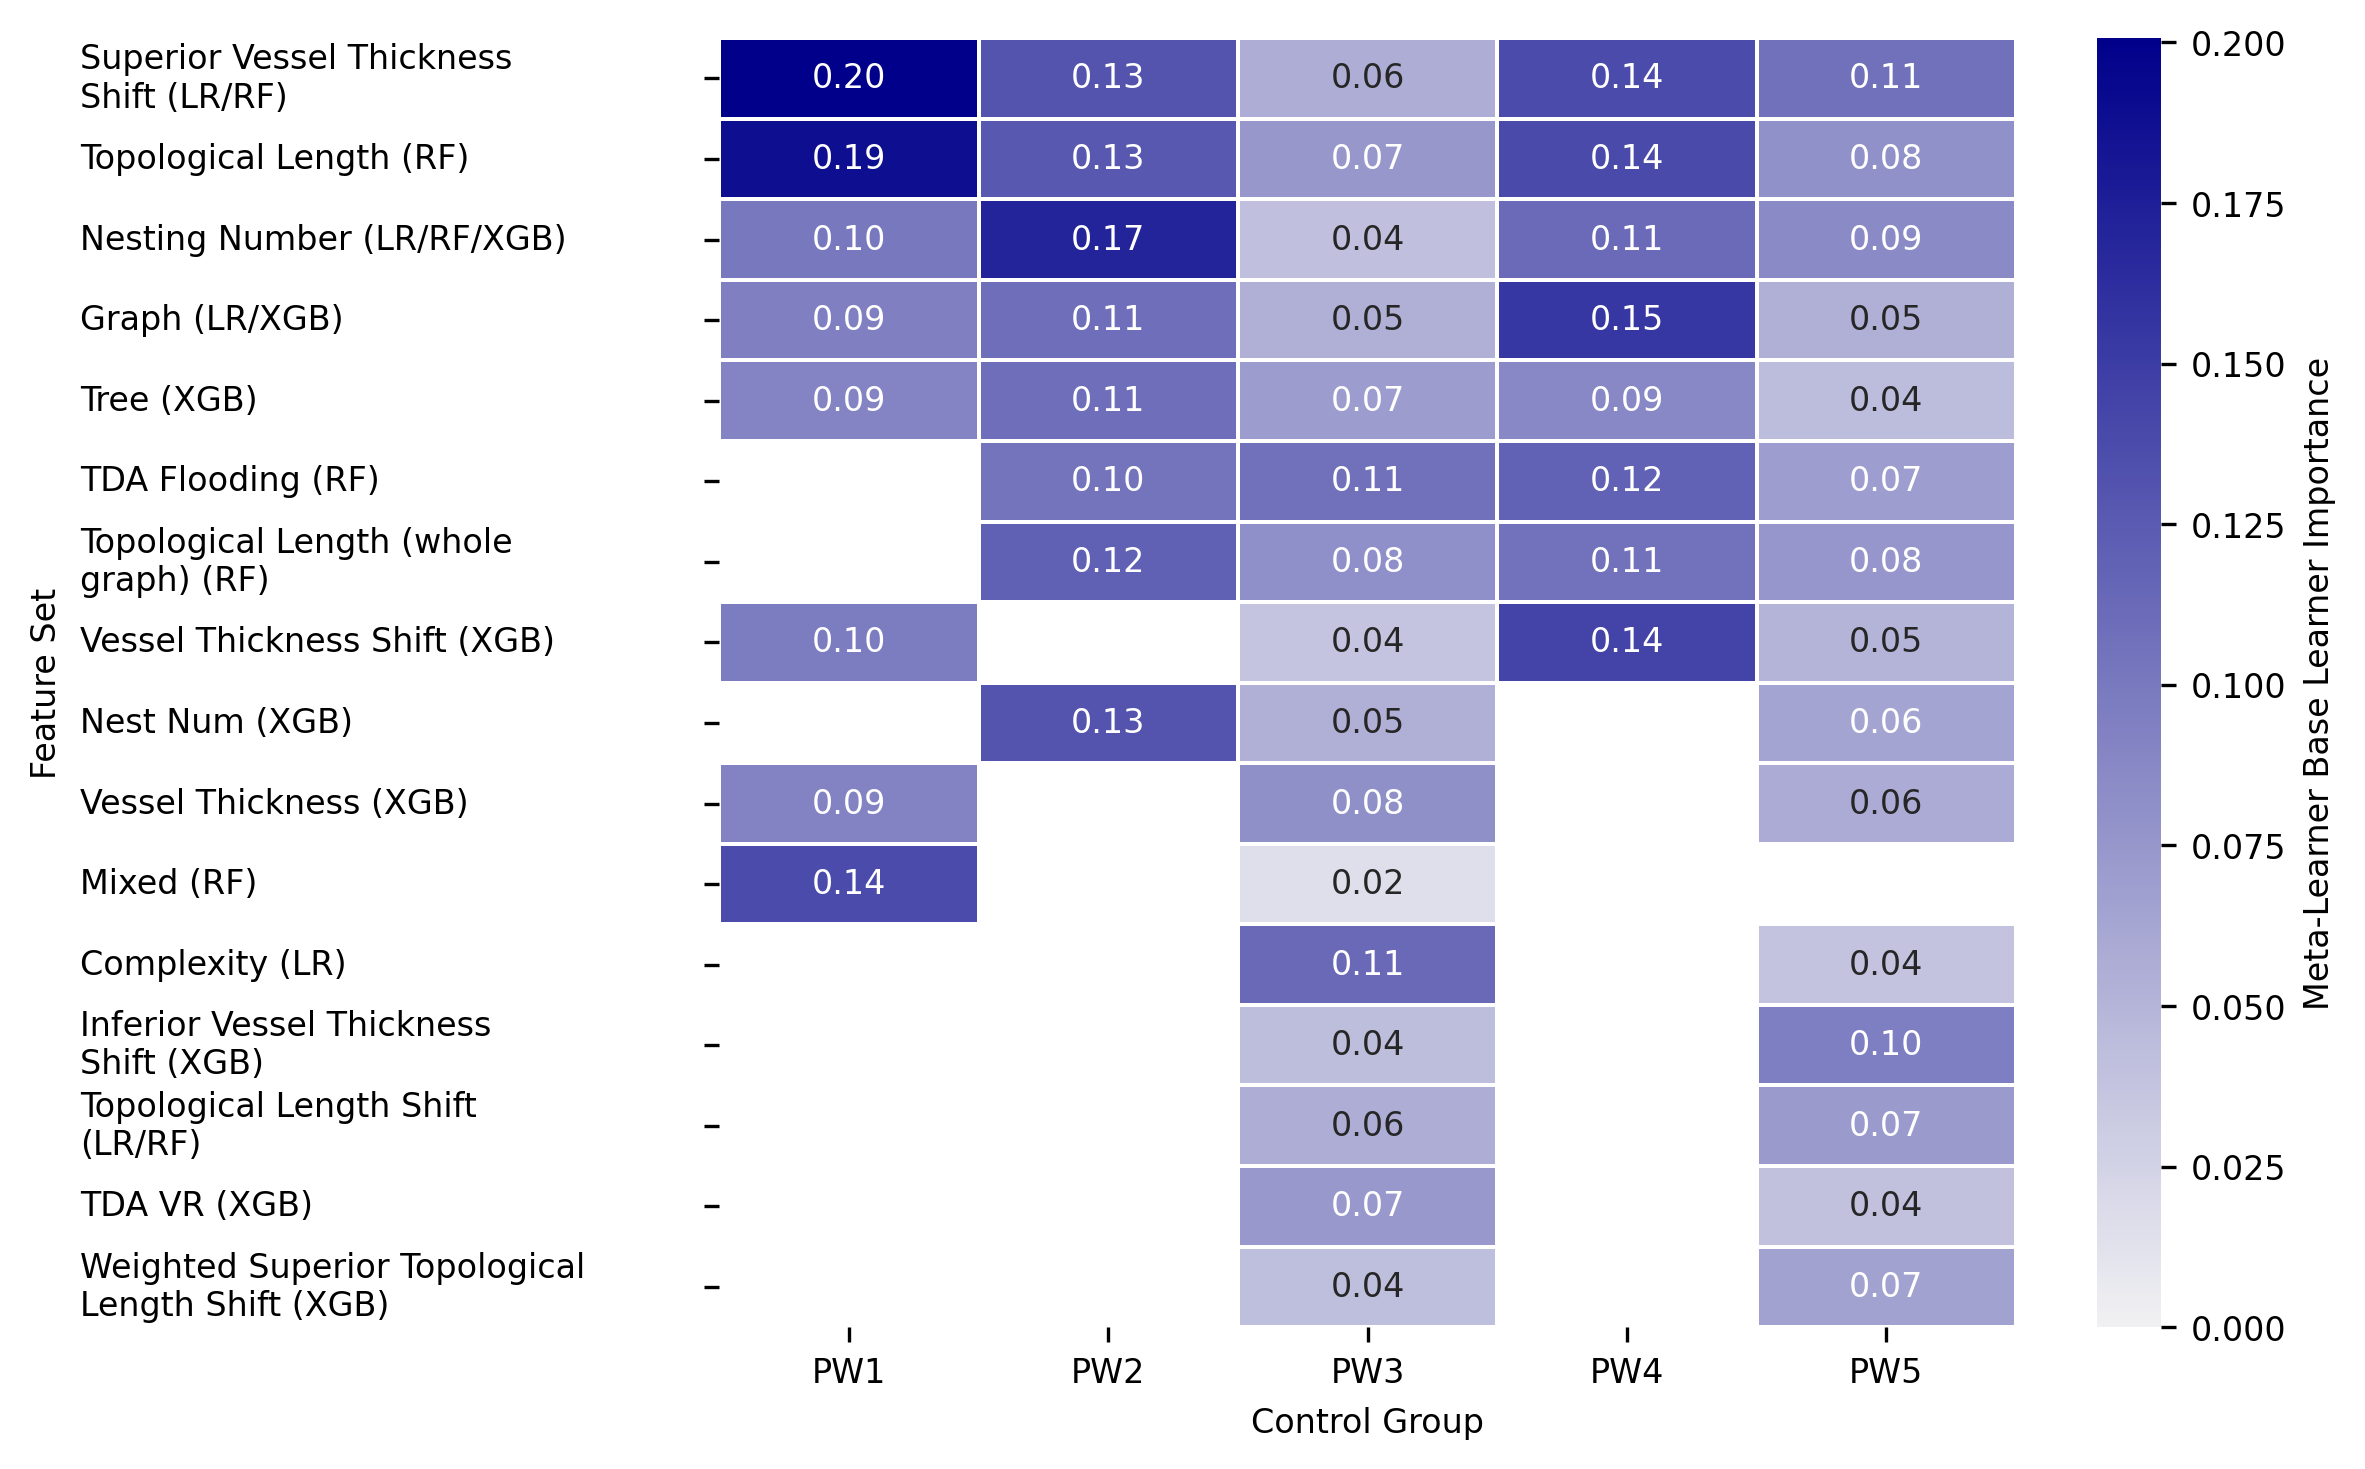

In [32]:
font_size = 12
get_test_feat_imp(data_name, train_test_run_models, n_pop=n_pop, model_type=model_type, cmap=sns.color_palette("light:darkblue", as_cmap=True), save_path='/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/main_text/fig_6/b.pdf')